# 04: Fault Discretization and G Matrix Construction

## Learning objectives
- Discretize a fault plane into many rectangular patches.
- Build Green's functions for patch slip.
- Plot slip maps and data overlays (vectors + vertical circles).

In [2]:
%load_ext autoreload
%autoreload 2
from okada_utils import fault_outline, build_patch_grid, build_component_greens

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import okada85

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

rng = np.random.default_rng(4)

In [3]:
def plot_fault_patches(ax, patches, slip=None, cmap='viridis', vmin=None, vmax=None):
    polys = [fault_outline(p['depth'], p['dip'], p['L'], p['W'], p['strike'], p['e'], p['n']) for p in patches]

    if slip is None:
        for poly in polys:
            ax.plot(poly[:, 0] / 1000.0, poly[:, 1] / 1000.0, color='k', linewidth=1.0)
        return None

    slip = np.asarray(slip)
    if vmin is None:
        vmin = float(np.min(slip))
    if vmax is None:
        vmax = float(np.max(slip))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

    for poly, s in zip(polys, slip):
        ax.fill(poly[:, 0] / 1000.0, poly[:, 1] / 1000.0, color=mapper.to_rgba(float(s)), edgecolor='k', linewidth=0.6)

    return mapper


def plot_data_overlay(ax, obs_e, obs_n, uE, uN, uU, quiver_step=2, quiver_scale=1):
    # infer grid shape from unique coordinates (for quiver downsampling)
    eu = np.unique(obs_e)
    nu = np.unique(obs_n)
    nx = eu.size
    ny = nu.size

    E = obs_e.reshape(ny, nx)
    N = obs_n.reshape(ny, nx)
    UE = uE.reshape(ny, nx)
    UN = uN.reshape(ny, nx)

    ax.quiver(
        E[::quiver_step, ::quiver_step] / 1000.0,
        N[::quiver_step, ::quiver_step] / 1000.0,
        UE[::quiver_step, ::quiver_step],
        UN[::quiver_step, ::quiver_step],
        color='k', scale=quiver_scale, width=0.003
    )

    sc = ax.scatter(obs_e / 1000.0, obs_n / 1000.0, c=uU, cmap='RdBu_r', s=24, edgecolor='k', linewidth=0.2)
    return sc

In [4]:
# Test case - 4 patches, 5 stations

# Geometry and patches
patches = build_patch_grid(e0=0, n0=0, z0=8e3, strike_deg=315, 
                           dip_deg=20, fault_L=40e3, fault_W=16e3, nL=2, nW=2)

# Print out the patch-specific values
display(patches)

# Observation points
obs_e = 1e3*np.array([10, 15, 20, -15, -30])
obs_n = 1e3*np.array([10, 30, -20, -15, 10])
# Build Green's functions for E/N/U components
GE, GN, GU = build_component_greens(obs_e, obs_n, patches, rake_deg=90.0)
G_stack = np.vstack([GE, GN, GU])
print(G_stack)

[{'i': 0,
  'j': 0,
  'e': 4413.215714310779,
  'n': -9728.919909420172,
  'depth': 9368.080573302675,
  'strike': 315.0,
  'dip': 20.0,
  'L': 20000.0,
  'W': 8000.0},
 {'i': 1,
  'j': 0,
  'e': -9728.919909420176,
  'n': 4413.215714310776,
  'depth': 9368.080573302675,
  'strike': 315.0,
  'dip': 20.0,
  'L': 20000.0,
  'W': 8000.0},
 {'i': 0,
  'j': 1,
  'e': 9728.919909420176,
  'n': -4413.215714310773,
  'depth': 6631.9194266973245,
  'strike': 315.0,
  'dip': 20.0,
  'L': 20000.0,
  'W': 8000.0},
 {'i': 1,
  'j': 1,
  'e': -4413.215714310779,
  'n': 9728.919909420176,
  'depth': 6631.9194266973245,
  'strike': 315.0,
  'dip': 20.0,
  'L': 20000.0,
  'W': 8000.0}]

[[-0.0209449  -0.04405212 -0.0286129  -0.07389653]
 [-0.00519987 -0.01571594 -0.0055358  -0.0243555 ]
 [ 0.00064413  0.00040784  0.01520096  0.00149636]
 [-0.01885071 -0.00465409  0.00320142  0.00386555]
 [-0.00228876 -0.02461535 -0.00038636 -0.00340417]
 [-0.04405212 -0.0209449  -0.07389653 -0.0286129 ]
 [-0.0127978  -0.0161225  -0.01629342 -0.0250901 ]
 [-0.00470119 -0.00085708 -0.02385493 -0.00126916]
 [-0.00465409 -0.01885071  0.00386555  0.00320142]
 [ 0.00218744  0.00692636  0.00152151  0.0032463 ]
 [-0.0219877  -0.0219877  -0.04367799 -0.04367799]
 [-0.00246068 -0.00427116 -0.00267436 -0.00568372]
 [-0.00119796 -0.00147433  0.00903675 -0.00162291]
 [ 0.01198794  0.01198794  0.00136807  0.00136807]
 [-0.00063605  0.01239843 -0.00091565  0.00121787]]


[-0.05199034 -0.01831246  0.00057661 -0.00412352 -0.02460671 -0.02395416
 -0.01879845 -0.00099175 -0.01816276  0.00719237 -0.02674686 -0.00486709
 -0.00164027  0.01194974  0.01233581]


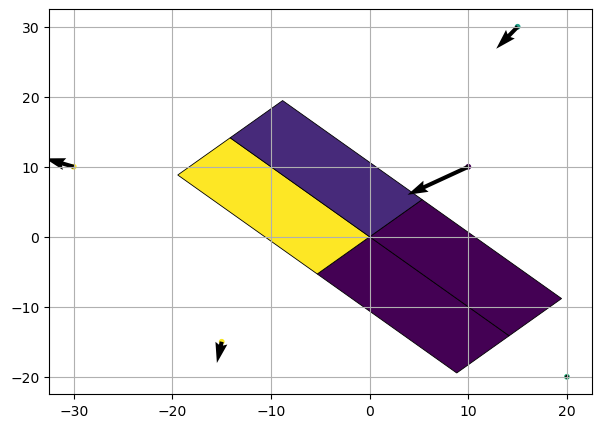

In [5]:
patchx = np.array([p['e'] for p in patches])
patchy = np.array([p['n'] for p in patches])

m = np.exp((-1*(patchx+10e3)**2-(patchy-5e3)**2)/5e3**2)

d_pred = G_stack @ m

print(d_pred)
fig,ax = plt.subplots()
plot_fault_patches(ax, patches,m)
plt.scatter(obs_e/1e3,obs_n/1e3,s=10,c=d_pred[10:15])
plt.quiver(obs_e/1e3,obs_n/1e3,d_pred[0:5],d_pred[5:10])


(15, 400)
(415, 400)
[-0.0028413  -0.00255217  0.0001138   0.00041886 -0.00406954  0.0013401
 -0.00211958 -0.00020541 -0.00395042  0.00169648  0.00074055 -0.00067271
 -0.00012203  0.00161291  0.0014447 ]
[-4.60233479e-03 -2.36938191e-03  1.91585440e-03  8.99577324e-03
  1.97629568e-02  3.50426903e-02  5.52049058e-02  7.96621389e-02
  1.06493703e-01  1.32585224e-01  1.54515864e-01  1.69879555e-01
  1.78256421e-01  1.81258871e-01  1.81804659e-01  1.83227642e-01
  1.88668243e-01  2.00732472e-01  2.21061764e-01  2.49318830e-01
 -4.55265490e-03 -2.43986725e-03  1.57102967e-03  8.16482189e-03
  1.81530296e-02  3.22683421e-02  5.08208271e-02  7.32747247e-02
  9.79512998e-02  1.22165798e-01  1.42965784e-01  1.58215297e-01
  1.67417223e-01  1.71815893e-01  1.73862071e-01  1.76489585e-01
  1.82559183e-01  1.94484386e-01  2.13758802e-01  2.39974443e-01
 -4.54098885e-03 -2.59882271e-03  1.06954009e-03  7.10834802e-03
  1.62722713e-02  2.92364337e-02  4.62908730e-02  6.69753126e-02
  8.98307602e-02

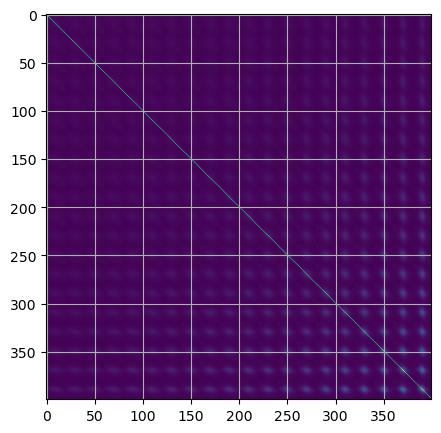

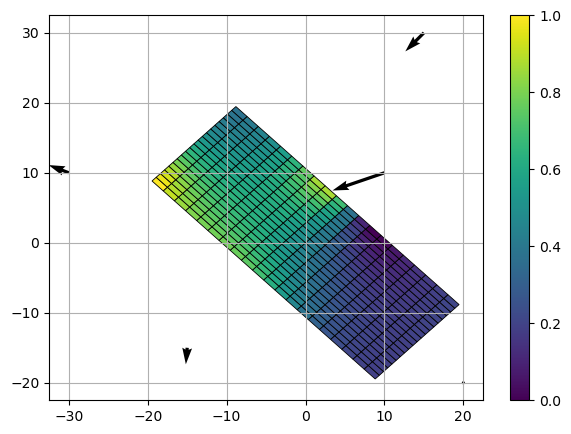

In [84]:
lam = 0.005
G_aug = np.vstack([G_stack,lam*np.eye(len(m))])
d_aug = np.concatenate([d_pred,np.zeros((len(m),))])
print(np.shape(G_stack))
print(np.shape(G_aug))

plt.imshow(G_aug.T @ G_aug)

m_pred = np.linalg.inv(G_aug.T @ G_aug) @ G_aug.T @ d_aug

d_fit = G_stack @ m_pred

print(d_pred - d_fit)

fig,ax = plt.subplots()
plot_fault_patches(ax, patches, m_pred)
#plt.scatter(obs_e/1e3,obs_n/1e3,s=10,c=d_pred[10:15])
plt.quiver(obs_e/1e3,obs_n/1e3,d_pred[0:5],d_pred[5:10])
plt.colorbar()

print(m_pred)

In [68]:
ds= np.concatenate([d_pred,np.zeros((len(m),))])
print(np.shape(ds))
print(np.shape(d_pred))

(415,)
(15,)


In [12]:
# Build Green's functions for E/N/U components
GE, GN, GU = build_component_greens(obs_e, obs_n, patches, rake_deg=90.0)

# Synthetic true slip (dip-slip only)
s_true = np.zeros(npatch)
s_true[0:5] = 1.0
s_true[8:10] = 0.7

print(s_true)

# Synthetic data
uE_true = GE @ s_true
uN_true = GN @ s_true
uU_true = GU @ s_true

noise_level = 0.02
sigE = noise_level * np.max(np.abs(uE_true))
sigN = noise_level * np.max(np.abs(uN_true))
sigU = noise_level * np.max(np.abs(uU_true))

uE_obs = uE_true + rng.normal(0.0, sigE, size=nobs)
uN_obs = uN_true + rng.normal(0.0, sigN, size=nobs)
uU_obs = uU_true + rng.normal(0.0, sigU, size=nobs)

# Stack linear system [E;N;U] = [GE;GN;GU] s
G_stack = np.vstack([GE, GN, GU])
d_stack = np.concatenate([uE_obs, uN_obs, uU_obs])

print(G_stack)

s_est, *_ = np.linalg.lstsq(G_stack, d_stack, rcond=None)

[1. 1. 1. 1.]
[[-0.0209449  -0.04405212 -0.0286129  -0.07389653]
 [-0.00519987 -0.01571594 -0.0055358  -0.0243555 ]
 [ 0.00064413  0.00040784  0.01520096  0.00149636]
 [-0.01885071 -0.00465409  0.00320142  0.00386555]
 [-0.00228876 -0.02461535 -0.00038636 -0.00340417]
 [-0.04405212 -0.0209449  -0.07389653 -0.0286129 ]
 [-0.0127978  -0.0161225  -0.01629342 -0.0250901 ]
 [-0.00470119 -0.00085708 -0.02385493 -0.00126916]
 [-0.00465409 -0.01885071  0.00386555  0.00320142]
 [ 0.00218744  0.00692636  0.00152151  0.0032463 ]
 [-0.0219877  -0.0219877  -0.04367799 -0.04367799]
 [-0.00246068 -0.00427116 -0.00267436 -0.00568372]
 [-0.00119796 -0.00147433  0.00903675 -0.00162291]
 [ 0.01198794  0.01198794  0.00136807  0.00136807]
 [-0.00063605  0.01239843 -0.00091565  0.00121787]]


In [5]:
# Geometry and patches
patches = build_patch_grid(
    e0=0.0, n0=0.0, z0=8000.0,
    strike_deg=315.0, dip_deg=20.0,
    fault_L=40000.0, fault_W=16000.0,
    nL=6, nW=2,
)
npatch = len(patches)
print('Number of patches:', npatch)

# Observation grid
e_axis = np.linspace(-35000, 35000, 13)
n_axis = np.linspace(-25000, 25000, 9)
E, N = np.meshgrid(e_axis, n_axis)
obs_e = E.ravel()
obs_n = N.ravel()
nobs = obs_e.size
print('Number of observations:', nobs)

Number of patches: 12
Number of observations: 117


In [18]:
# Build Green's functions for E/N/U components
GE, GN, GU = build_component_greens(obs_e, obs_n, patches, rake_deg=90.0)

# Synthetic true slip (dip-slip only)
s_true = np.zeros(npatch)
s_true[2:5] = 1.0
s_true[8:10] = 0.7

# Synthetic data
uE_true = GE @ s_true
uN_true = GN @ s_true
uU_true = GU @ s_true

noise_level = 0.02
sigE = noise_level * np.max(np.abs(uE_true))
sigN = noise_level * np.max(np.abs(uN_true))
sigU = noise_level * np.max(np.abs(uU_true))

uE_obs = uE_true + rng.normal(0.0, sigE, size=nobs)
uN_obs = uN_true + rng.normal(0.0, sigN, size=nobs)
uU_obs = uU_true + rng.normal(0.0, sigU, size=nobs)

# Stack linear system [E;N;U] = [GE;GN;GU] s
G_stack = np.vstack([GE, GN, GU])
d_stack = np.concatenate([uE_obs, uN_obs, uU_obs])

s_est, *_ = np.linalg.lstsq(G_stack, d_stack, rcond=None)

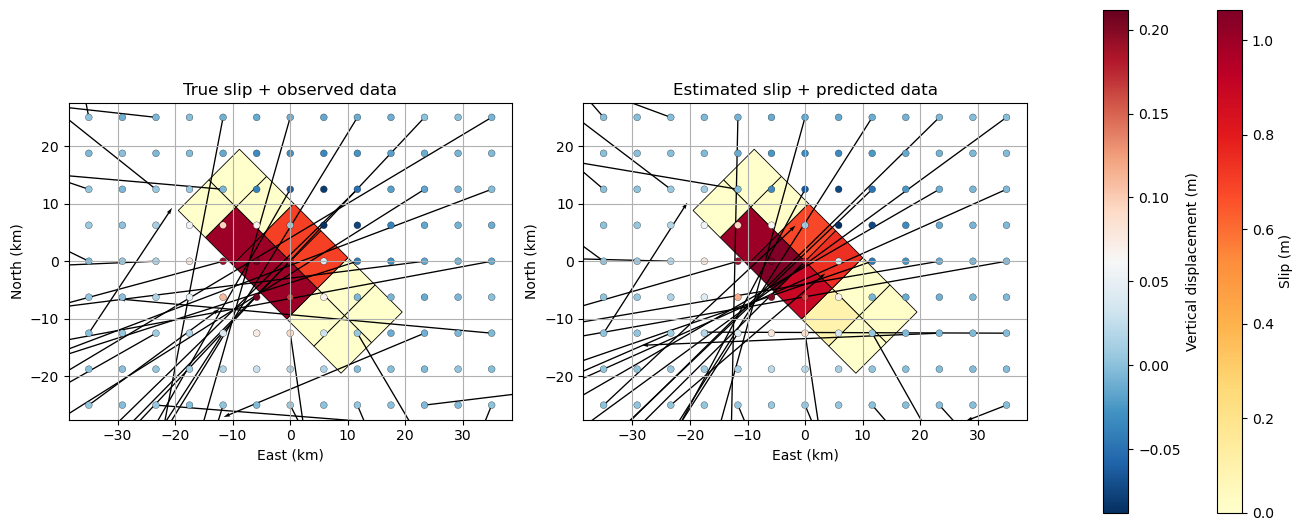

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

vmin = 0.0
vmax = max(float(np.max(s_true)), float(np.max(s_est)))

m1 = plot_fault_patches(axes[0], patches, slip=s_true, cmap='YlOrRd', vmin=vmin, vmax=vmax)
sc1 = plot_data_overlay(axes[0], obs_e, obs_n, uE_obs, uN_obs, uU_obs, quiver_step=2, quiver_scale=0.01)
axes[0].set_title('True slip + observed data')
axes[0].set_xlabel('East (km)')
axes[0].set_ylabel('North (km)')
axes[0].set_aspect('equal')

m2 = plot_fault_patches(axes[1], patches, slip=s_est, cmap='YlOrRd', vmin=vmin, vmax=vmax)
uE_pred = GE @ s_est
uN_pred = GN @ s_est
uU_pred = GU @ s_est
sc2 = plot_data_overlay(axes[1], obs_e, obs_n, uE_pred, uN_pred, uU_pred, quiver_step=2, quiver_scale=0.01)
axes[1].set_title('Estimated slip + predicted data')
axes[1].set_xlabel('East (km)')
axes[1].set_ylabel('North (km)')
axes[1].set_aspect('equal')

cbar_slip = plt.colorbar(m2, ax=axes, fraction=0.03, pad=0.02)
cbar_slip.set_label('Slip (m)')

cbar_u = plt.colorbar(sc2, ax=axes, fraction=0.03, pad=0.08)
cbar_u.set_label('Vertical displacement (m)')

plt.show()

## Summary
- You discretized a fault and built $G$ from unit-slip patch responses.
- You inverted for slip using stacked E/N/U data.
- You visualized both slip patches and data (vectors + vertical circles) on the same map.